# Optimal control of primary drying: replicating Srisuma and Braatz (2025)

This notebook reproduces both optimal-control case studies from Srisuma and Braatz, [*Highly Efficient Optimal Control for Lyophilization via Simulation of Discrete/Continuous Mixed-index Differential-algebraic Equations*](https://arxiv.org/abs/2509.10826), arXiv:2509.10826v1 (2025), with upstream MATLAB/GEKKO code at [PrakitrSrisuma/simDAE-optimalcontrol-lyo](https://github.com/PrakitrSrisuma/simDAE-optimalcontrol-lyo).

The paper's contribution is an algorithm. Rather than solving primary-drying optimal control as a nonlinear program, it reformulates the problem as a hybrid discrete/continuous system of mixed-index differential-algebraic equations and *simulates* it, switching between three control policies as path constraints become active:

| Policy | Control law | Differential index |
| --- | --- | ---: |
| 1: maximum heat input | $T_\mathrm{b}(t) = T_\mathrm{b,max}$ | 1 |
| 2: product temperature tracking | $T_n(t) = T_\mathrm{sp}$ | 2 |
| 3: sublimation flux tracking | $\mathrm{d}S/\mathrm{d}t = v_\mathrm{sp}$ | $n+1$ (21 for $n=20$) |

The paper reports that this is several orders of magnitude faster than optimization-based control while giving similar or better accuracy.

**What this notebook does.** It solves the paper's two case studies by the *other* route — the simultaneous, optimization-based one the paper benchmarks against — using LyoPRONTO's Pyomo.DAE stack, and asks two questions:

1. **Does LyoPRONTO recover the published solutions?** Drying times, policy-switch times, and the full policy sequence are compared against the paper's reported values.
2. **Is optimization-based control really orders of magnitude slower?** The upstream repository publishes IPOPT timings of 1015.84 s and 64.60 s against 0.58 s for the simulation-based method. Those optimization scripts were never released, so this notebook's transcription is an independent attempt at the same route.

The final section shows that the paper's three-policy taxonomy is not specific to its model: LyoPRONTO's existing sequential optimizer `opt_Tsh` already selects among exactly these three policies at vial scale, by active constraint.

## Setup

Run this notebook from the repository root. Pyomo and IPOPT are optional dependencies:

```bash
python -m pip install -e ".[dev,pyomo]"
idaes get-extensions --extra petsc
jupyter lab docs/examples/paper_optimal_control_replication.ipynb
```

In [1]:
# Papermill parameters. CI uses a coarser mesh and fewer timing repeats.
n_z = 20
nfe = 36
ncp = 3
terminal_drying_fraction = 0.995
terminal_fraction_sweep = [0.99, 0.995]
timing_repeats = 3
mesh_sweep = [[5, 12], [10, 24], [20, 24], [20, 36], [20, 48]]
vial_dt = 0.02
capability_scale = 0.16
shelf_temperature_max_c = 70.0

In [2]:
from importlib.metadata import version
from pathlib import Path
import platform
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from examples.paper_optimal_control_replication import (
    PAPER_REFERENCE,
    classify_vial_policies,
    complete_drying_residual_hr,
    extrapolated_complete_drying_time_hr,
    mesh_sensitivity_rows,
    paper_comparison_rows,
    paper_reference_deviation_percent,
    policy_label,
    run_paper_case,
    run_vial_policy_case,
    shelf_bound_switch_brackets_hr,
    terminal_fraction_sensitivity_rows,
    switch_brackets_contain_published,
    vial_policy_inputs,
)
from lyopronto.pyomo_models import paper_ocp

# Record the source revision so committed outputs can be tied to the code
# that produced them.
git_revision = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
).stdout.strip() or "unknown"

print(
    f"LyoPRONTO {version('lyopronto')} | "
    f"SciPy {version('scipy')} | Pyomo {version('pyomo')} | "
    f"git_revision {git_revision}"
)
print(f"host CPU: {platform.processor() or platform.machine()}")
print(f"paper reference: {PAPER_REFERENCE['citation']}")
print(f"upstream commit: {PAPER_REFERENCE['upstream_commit']}")

LyoPRONTO 1.1.0 | SciPy 1.17.1 | Pyomo 6.9.5 | git_revision 35fb3f7d12250d0d8f5a15d4bfad11ae4c0c7219
host CPU: x86_64
paper reference: Srisuma and Braatz, arXiv:2509.10826v1 (2025)
upstream commit: 5bcfece23128be7e5be51b73693dc6674223ccc6


## The model

Primary drying of a suspended vial is modelled in one spatial dimension. Heat conducts through the *frozen* region only; the dried layer above the moving sublimation front is not resolved thermally.

$$\rho_\mathrm{f} C_{p,\mathrm{f}} \frac{\partial T}{\partial t} = k_\mathrm{f} \frac{\partial^2 T}{\partial z^2} + \frac{Q_\mathrm{rad}}{V_\mathrm{f}}, \qquad S(t) < z < H$$

with the sublimation front at $z = S(t)$, the shelf-contacted bottom at $z = H$, and

$$\frac{\mathrm{d}S}{\mathrm{d}t} = \frac{N_\mathrm{w}}{\rho_\mathrm{f} - \rho_\mathrm{e}}, \qquad N_\mathrm{w} = \frac{p_\mathrm{w,sat}(T_1) - p_\mathrm{w,c}}{R_p(S)}$$

The domain shrinks as drying proceeds, so `lyopronto.pyomo_models.paper_ocp` solves the problem on the Landau-transformed coordinate $\psi = (z - S)/(H - S) \in [0, 1]$, discretized with $n_z$ nodes by the method of lines. Node 1 is the sublimation front and node $n_z$ is the vial bottom. Three details of the upstream implementation are easy to get wrong and are reproduced deliberately:

- The **front boundary condition** balances conduction against both the sublimation load and radiation from the top surface: $k_\mathrm{f}\, \partial T/\partial z = N_\mathrm{w} \Delta H_\mathrm{sub} + \mathcal{F}_\mathrm{top} \sigma (T_1^4 - T_\mathrm{u}^4)$.
- The **bottom boundary condition** is pure contact conduction to the shelf, $k_\mathrm{f}\, \partial T/\partial z = h_\mathrm{b}(T_\mathrm{b} - T_n)$, with no shelf radiation.
- **Side radiation** enters every node as a volumetric source using the *full-height* area $A_r = \pi d H$ divided by the *shrinking* frozen volume $V_\mathrm{f} = A_c (H - S)$, so the effective volumetric gain grows during drying.

The product temperature that the constraints act on is $T_n$, the bottom node, because the profile peaks there.

Parameters are translated from the upstream `Input Data/get_inputdata.m` and `input_processing.m`. The cell below derives the geometry and effective properties from them.

In [3]:
config = paper_ocp.PaperPrimaryDryingConfig()
derived = paper_ocp.derive_primary_drying_parameters(config, n_z=n_z)

rows = [
    ("frozen density rho_f", derived.frozen_density, "kg/m^3"),
    ("dried region density rho_e", config.dried_region_density, "kg/m^3"),
    ("frozen heat capacity Cp_f", derived.frozen_heat_capacity, "J/kg/K"),
    ("frozen conductivity k_f", derived.frozen_conductivity, "W/m/K"),
    ("thermal diffusivity alpha_f", derived.frozen_diffusivity, "m^2/s"),
    ("product height H", derived.product_height, "m"),
    ("cross-section area A_c", derived.cross_section_area, "m^2"),
    ("side radiation area A_r", derived.side_area, "m^2"),
    ("side transfer factor F_side", derived.side_transfer_factor, "-"),
    ("top transfer factor F_top", derived.top_transfer_factor, "-"),
    ("shelf contact coefficient h_b", config.bottom_heat_transfer_coefficient, "W/m^2/K"),
    ("chamber water pressure p_w,c", config.chamber_water_pressure, "Pa"),
    ("initial temperature T_0", config.initial_temperature, "K"),
    ("wall / top temperature T_c = T_u", config.wall_temperature, "K"),
]
print(f"{'parameter':32s} {'value':>14s}  units")
for name, value, units in rows:
    print(f"{name:32s} {value:14.6g}  {units}")

# Cake resistance R_p(S) = R_p0 + R_p1 S / (1 + R_p2 S) grows as the dried
# layer thickens, which is what slows sublimation late in the cycle.
print()
for position in (0.0, 0.5 * derived.product_height, derived.product_height):
    print(
        f"R_p(S = {position * 1e3:5.2f} mm) = "
        f"{paper_ocp.product_resistance(position, config):.4g} m/s"
    )

# The initial interface velocity already exceeds Problem 2's limit, which is why
# that case starts on Policy 3 rather than Policy 1.
initial_velocity = paper_ocp.interface_velocity(
    config.initial_temperature, 0.0, config, derived
)
print(
    f"\ninitial dS/dt = {initial_velocity:.4g} m/s vs Problem 2 limit "
    f"{PAPER_REFERENCE['problem2']['interface_velocity_limit_m_per_s']:.2g} m/s"
)

assert abs(derived.product_height - 7.2124e-3) < 1.0e-6, derived.product_height
assert abs(derived.frozen_density - 936.79) < 0.01, derived.frozen_density
assert initial_velocity > PAPER_REFERENCE["problem2"]["interface_velocity_limit_m_per_s"]

parameter                                 value  units
frozen density rho_f                     936.79  kg/m^3
dried region density rho_e                  215  kg/m^3
frozen heat capacity Cp_f                2064.6  J/kg/K
frozen conductivity k_f                  2.1438  W/m/K
thermal diffusivity alpha_f         1.10842e-06  m^2/s
product height H                     0.00721243  m
cross-section area A_c              0.000452389  m^2
side radiation area A_r             0.000543804  m^2
side transfer factor F_side               0.624  -
top transfer factor F_top                   0.8  -
shelf contact coefficient h_b                25  W/m^2/K
chamber water pressure p_w,c                  3  Pa
initial temperature T_0                     228  K
wall / top temperature T_c = T_u            240  K

R_p(S =  0.00 mm) = 1.5e+04 m/s
R_p(S =  3.61 mm) = 1.194e+05 m/s
R_p(S =  7.21 mm) = 2.168e+05 m/s

initial dS/dt = 3.798e-07 m/s vs Problem 2 limit 2.8e-07 m/s


## Problem 1: minimum drying time under a product-temperature limit

$$\min_{T_\mathrm{b}(t)}\ t_f \quad \text{s.t.}\quad T(z,t) \le 243\ \mathrm{K},\qquad 228\ \mathrm{K} \le T_\mathrm{b}(t) \le 273\ \mathrm{K}$$

The paper reports that the optimal solution uses Policy 1 followed by Policy 2, switching at 2.4 h: the shelf is held at its 273 K ceiling until the product reaches its 243 K limit, after which the shelf temperature must fall to keep the product exactly at that limit.

LyoPRONTO solves the same problem as a single nonlinear program — free final time, LAGRANGE-RADAU collocation on the time domain — and then classifies which path constraint is active at each point. The sequence is read back from the solution rather than imposed on it.

For that reading to mean anything, the solve must not be told the answer first. `paper_ocp` ships a policy-sequenced warm start that seeds the published order and, for Problem 2, its 2.0 h and 3.9 h switch guesses; a run initialized that way cannot be cited as independent recovery of the sequence. Every headline solve in this notebook is therefore **cold started** (`initialization=None`), which is the default of `run_paper_case`. The warm start is compared against it further down.

There is a second thing to be explicit about before reading any drying time below. The paper's cycle ends at $S = H$, but this transcription cannot: the model lives on the Landau coordinate $\psi = (z-S)/(H-S)$, whose conduction term carries a $1/(H-S)^2$ factor, so the equations are singular exactly at $S = H$. Solves therefore stop at a cutoff fraction of the height — 0.995 here — and the reported time is short of the paper's by the sliver that remains. Both numbers are reported below, and the section after Figure 3 shows the cutoff dependence and how the residual is estimated.

In [4]:
problem1 = run_paper_case(
    "problem1", n_z=n_z, nfe=nfe, ncp=ncp,
    terminal_drying_fraction=terminal_drying_fraction,
    timing_repeats=timing_repeats,
)

print(f"termination: {problem1.solution['metadata']['termination_condition']}")
print(f"initialization: {problem1.initialization}, "
      f"terminal cutoff: S = {problem1.terminal_drying_fraction:g} H")
print(f"drying time to the cutoff: {problem1.drying_time_hr:.3f} h")
print(f"residual to S = H:         {complete_drying_residual_hr(problem1):.3f} h")
print(f"extrapolated to S = H:     {extrapolated_complete_drying_time_hr(problem1):.3f} h "
      f"({paper_reference_deviation_percent(problem1):+.2f}% vs published)")
print(f"median solve: {problem1.wall_median_s:.2f} s\n")

print(f"{'quantity':30s} {'paper':>8s} {'LyoPRONTO':>18s}  source")
for row in paper_comparison_rows(problem1):
    if row["lyopronto_low"] == row["lyopronto_high"]:
        solved = f"{row['lyopronto_low']:.3f}"
    else:
        solved = f"[{row['lyopronto_low']:.3f}, {row['lyopronto_high']:.3f}]"
    published = "--" if np.isnan(row["paper"]) else f"{row['paper']:.2f}"
    print(f"{row['quantity']:30s} {published:>8s} {solved:>18s}  {row['note']}")

bracket1, = shelf_bound_switch_brackets_hr(problem1)
contains = switch_brackets_contain_published(problem1)
print(f"published switch time inside the solved bracket: {contains[0]}")

print("\npolicy sequence:")
for segment in problem1.solution["policies"]["segments"]:
    print(f"  {policy_label(segment['label']):42s} "
          f"{segment['start_time_hr']:5.2f} - {segment['end_time_hr']:5.2f} h")

metrics1 = problem1.solution["metrics"]
print(f"\nmax product temperature: {metrics1['max_product_temperature_K']:.3f} K "
      f"(limit {PAPER_REFERENCE['problem1']['temperature_limit_K']:.0f} K, "
      f"violation {metrics1['max_temperature_violation_K']:.1e} K)")

assert problem1.terminated_optimally
assert problem1.policy_sequence == PAPER_REFERENCE["problem1"]["policy_sequence"]
assert abs(paper_reference_deviation_percent(problem1)) < 5.0
# The bracket must sit on the published switch time. Whether it strictly
# contains it depends on where the mesh points happen to fall, so that is
# reported above rather than asserted; the mesh sweep below shows the trend.
assert abs(0.5 * (bracket1[0] + bracket1[1]) - 2.4) < 0.5, bracket1
assert metrics1["max_temperature_violation_K"] < 1.0e-4

termination: optimal
initialization: cold, terminal cutoff: S = 0.995 H
drying time to the cutoff: 6.187 h
residual to S = H:         0.045 h
extrapolated to S = H:     6.232 h (+0.51% vs published)
median solve: 1.56 s

quantity                          paper          LyoPRONTO  source
drying time to S=0.995H [hr]         --              6.187  solver endpoint, short of the paper's S=H
drying time to S=H [hr]            6.20              6.232  read from Figure 2
policy switch 1 [hr]               2.40     [2.345, 2.406]  stated in Section V
published switch time inside the solved bracket: True

policy sequence:
  Policy 1: maximum heat input                0.00 -  2.09 h
  Policy 2: product temperature tracking      2.17 -  6.19 h

max product temperature: 243.000 K (limit 243 K, violation 2.4e-06 K)


### Figure 2

The panels below correspond to Figure 2 of the paper: shelf temperature, product temperature at the bottom node, interface position, and interface velocity, with the policy switch marked.

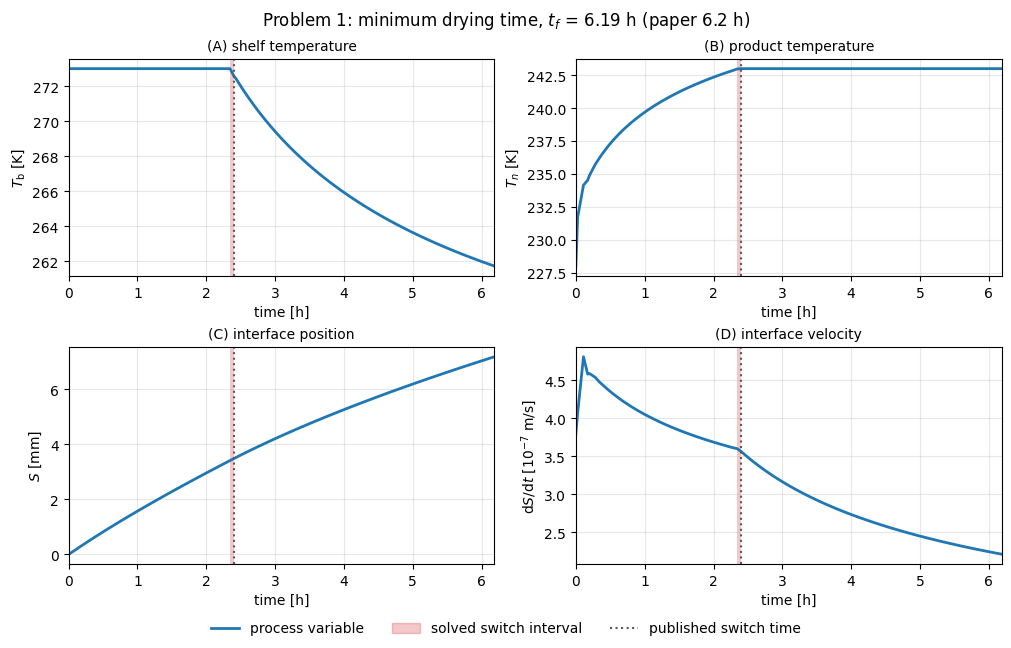

In [5]:
def plot_paper_case(run, title):
    "Draw the four-panel view of one solved case."
    states = run.solution["states"]
    controls = run.solution["controls"]
    time_hr = np.asarray(states["time_hr"])
    bottom_temperature = np.asarray(states["temperature_K"])[:, -1]

    # The constrained product temperature is the bottom node, which is also the
    # hottest point of the profile.
    assert np.allclose(bottom_temperature, np.asarray(states["max_temperature_K"]))

    panels = [
        ("(A) shelf temperature", np.asarray(controls["shelf_temperature_K"]), "$T_\\mathrm{b}$ [K]", 1.0),
        ("(B) product temperature", bottom_temperature, "$T_n$ [K]", 1.0),
        ("(C) interface position", np.asarray(states["interface_position_m"]) * 1e3, "$S$ [mm]", 1.0),
        ("(D) interface velocity", np.asarray(states["interface_velocity_m_per_s"]) * 1e7, "$\\mathrm{d}S/\\mathrm{d}t$ [$10^{-7}$ m/s]", 1.0),
    ]

    # Mark each switch as the interval the collocation mesh resolves it to,
    # taken from where the shelf control meets and leaves its upper bound. A
    # single line would claim a precision the solution does not have.
    brackets = shelf_bound_switch_brackets_hr(run)
    published = PAPER_REFERENCE[run.problem]["switch_times_hr"]

    figure, axes = plt.subplots(2, 2, figsize=(10.0, 6.4), layout="constrained")
    for axis, (label, values, ylabel, _) in zip(axes.ravel(), panels):
        axis.plot(time_hr, values, color="tab:blue", linewidth=2.0)
        for low, high in brackets:
            axis.axvspan(low, high, color="tab:red", alpha=0.25, linewidth=0)
        for switch in published:
            axis.axvline(switch, color="0.35", linestyle=":", linewidth=1.5)
        axis.set_title(label, fontsize=10)
        axis.set_xlabel("time [h]")
        axis.set_ylabel(ylabel)
        axis.set_xlim(0.0, time_hr[-1])
        axis.grid(alpha=0.3)

    handles = [
        plt.Line2D([], [], color="tab:blue", linewidth=2.0, label="process variable"),
        plt.Rectangle((0, 0), 1, 1, color="tab:red", alpha=0.25,
                      label="solved switch interval"),
        plt.Line2D([], [], color="0.35", linestyle=":", linewidth=1.5,
                   label="published switch time"),
    ]
    figure.legend(handles=handles, loc="outside lower center", ncol=3, frameon=False)
    figure.suptitle(title)
    return figure


figure = plot_paper_case(
    problem1,
    f"Problem 1: minimum drying time, $t_f$ = {problem1.drying_time_hr:.2f} h "
    f"(paper {PAPER_REFERENCE['problem1']['drying_time_hr']:.1f} h)",
)
plt.show()

## Problem 2: adding an interface-velocity constraint

$$\min_{T_\mathrm{b}(t)}\ t_f \quad \text{s.t.}\quad T(z,t) \le 240\ \mathrm{K},\qquad \frac{\mathrm{d}S}{\mathrm{d}t} \le 2.8 \times 10^{-7}\ \mathrm{m/s},\qquad 228\ \mathrm{K} \le T_\mathrm{b}(t) \le 260\ \mathrm{K}$$

Capping the interface velocity caps the sublimation flux, which is how a real cycle avoids overwhelming the condenser or choking the vapour path. It changes the structure of the answer: as the parameter cell above showed, the interface velocity at $t = 0$ is already above the cap, so the cycle *starts* on Policy 3, and the paper reports the sequence Policy 3 → Policy 1 → Policy 2 with switches at 2.0 h and 3.9 h.

This is the case that motivates the paper's algorithm, because Policy 3 is an index-21 DAE at the paper's $n = 20$ spatial mesh. In the simultaneous formulation the high index never appears: the velocity limit is just an inequality path constraint, and the optimizer discovers when to sit on it.

In [6]:
problem2 = run_paper_case(
    "problem2", n_z=n_z, nfe=nfe, ncp=ncp,
    terminal_drying_fraction=terminal_drying_fraction,
    timing_repeats=timing_repeats,
)

print(f"termination: {problem2.solution['metadata']['termination_condition']}")
print(f"initialization: {problem2.initialization}, "
      f"terminal cutoff: S = {problem2.terminal_drying_fraction:g} H")
print(f"drying time to the cutoff: {problem2.drying_time_hr:.3f} h")
print(f"residual to S = H:         {complete_drying_residual_hr(problem2):.3f} h")
print(f"extrapolated to S = H:     {extrapolated_complete_drying_time_hr(problem2):.3f} h "
      f"({paper_reference_deviation_percent(problem2):+.2f}% vs published)")
print(f"median solve: {problem2.wall_median_s:.2f} s\n")

print(f"{'quantity':30s} {'paper':>8s} {'LyoPRONTO':>18s}  source")
for row in paper_comparison_rows(problem2):
    if row["lyopronto_low"] == row["lyopronto_high"]:
        solved = f"{row['lyopronto_low']:.3f}"
    else:
        solved = f"[{row['lyopronto_low']:.3f}, {row['lyopronto_high']:.3f}]"
    published = "--" if np.isnan(row["paper"]) else f"{row['paper']:.2f}"
    print(f"{row['quantity']:30s} {published:>8s} {solved:>18s}  {row['note']}")

brackets2 = shelf_bound_switch_brackets_hr(problem2)
contains = switch_brackets_contain_published(problem2)
print(f"published switch times inside the solved brackets: {contains}")

print("\npolicy sequence:")
for segment in problem2.solution["policies"]["segments"]:
    print(f"  {policy_label(segment['label']):42s} "
          f"{segment['start_time_hr']:5.2f} - {segment['end_time_hr']:5.2f} h")

metrics2 = problem2.solution["metrics"]
velocity_limit = PAPER_REFERENCE["problem2"]["interface_velocity_limit_m_per_s"]
print(f"\nmax product temperature: {metrics2['max_product_temperature_K']:.3f} K "
      f"(limit {PAPER_REFERENCE['problem2']['temperature_limit_K']:.0f} K)")
print(f"peak dS/dt after the initial point: "
      f"{metrics2['max_post_initial_interface_velocity_m_per_s']:.4g} m/s "
      f"(limit {velocity_limit:.2g} m/s)")

assert problem2.terminated_optimally
assert problem2.policy_sequence == PAPER_REFERENCE["problem2"]["policy_sequence"]
assert abs(paper_reference_deviation_percent(problem2)) < 5.0
published2 = PAPER_REFERENCE["problem2"]["switch_times_hr"]
for bracket, published in zip(brackets2, published2):
    assert abs(0.5 * (bracket[0] + bracket[1]) - published) < 0.5, (bracket, published)
assert metrics2["max_post_initial_interface_velocity_m_per_s"] <= velocity_limit * (1.0 + 1.0e-6)
assert metrics2["max_temperature_violation_K"] < 1.0e-4

termination: optimal
initialization: cold, terminal cutoff: S = 0.995 H
drying time to the cutoff: 8.835 h
residual to S = H:         0.064 h
extrapolated to S = H:     8.900 h (-0.01% vs published)
median solve: 2.47 s

quantity                          paper          LyoPRONTO  source
drying time to S=0.995H [hr]         --              8.835  solver endpoint, short of the paper's S=H
drying time to S=H [hr]            8.90              8.900  stated in Section V-B
policy switch 1 [hr]               2.00     [1.963, 2.001]  stated in Section V
policy switch 2 [hr]               3.90     [3.840, 3.927]  stated in Section V
published switch times inside the solved brackets: [True, True]

policy sequence:
  Policy 3: sublimation flux tracking         0.00 -  2.00 h
  Policy 1: maximum heat input                2.12 -  3.47 h
  Policy 2: product temperature tracking      3.59 -  8.84 h

max product temperature: 240.000 K (limit 240 K)
peak dS/dt after the initial point: 2.8e-07 m/s (limi

### Figure 3

The same four panels for Problem 2, now with two policy switches. Panel (D) shows the interface velocity pinned at its $2.8 \times 10^{-7}$ m/s limit through the Policy 3 segment and falling away once the shelf bound takes over.

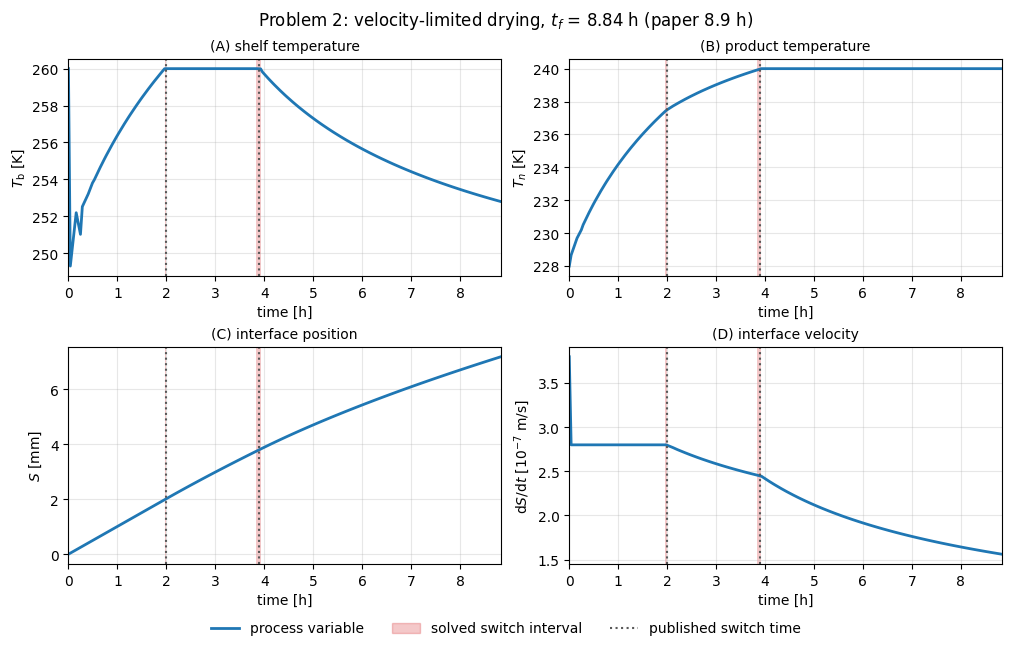

In [7]:
figure = plot_paper_case(
    problem2,
    f"Problem 2: velocity-limited drying, $t_f$ = {problem2.drying_time_hr:.2f} h "
    f"(paper {PAPER_REFERENCE['problem2']['drying_time_hr']:.1f} h)",
)
plt.show()

## The terminal endpoint, and what the drying time is actually measuring

Every drying time above stops at $S = 0.995H$, not at the paper's $S = H$. That is not a tuning choice that could be tightened away. On the Landau coordinate the conduction term carries a $1/(H-S)^2$ factor, so the frozen-region equations become singular exactly at the endpoint the paper terminates on, and `paper_ocp` rejects a cutoff fraction of 1 outright.

Tightening the cutoff does not help either, for the same reason: at $n_z = 20$, $nfe = 36$ the 0.99 and 0.995 cutoffs terminate optimally in about two seconds, while 0.999 and 0.9995 exhaust IPOPT's iteration limit after roughly four minutes and return a non-optimal point. Reporting one of those as the headline would be worse than reporting a converged truncated one.

So the residual is estimated instead of solved. Late in primary drying the interface velocity is smooth and slowly varying, so carrying the terminal velocity across the remaining thickness gives

$$t_f(S = H) \;\approx\; t_f(S = fH) \;+\; \frac{(1-f)H}{\left. \mathrm{d}S/\mathrm{d}t \right|_{t_f}}$$

The check that this is sound is that the estimate must not depend on where the solve was truncated. The sweep below evaluates it at two cutoffs whose raw times differ by several minutes.

In [8]:
for problem, run in (("problem1", problem1), ("problem2", problem2)):
    rows = terminal_fraction_sensitivity_rows(
        problem, terminal_fraction_sweep, n_z=n_z, nfe=nfe, ncp=ncp
    )
    published = PAPER_REFERENCE[problem]["drying_time_hr"]
    print(f"{problem} (published {published} h, {PAPER_REFERENCE[problem]['drying_time_source']})")
    print(f"  {'cutoff':>8s} {'raw [h]':>9s} {'residual [h]':>13s} {'extrapolated [h]':>17s} "
          f"{'termination':>12s}")
    for row in rows:
        print(f"  {row['terminal_drying_fraction']:8g} {row['drying_time_hr']:9.4f} "
              f"{row['residual_hr']:13.4f} {row['extrapolated_hr']:17.4f} "
              f"{row['termination']:>12s}")

    extrapolated = np.array([row["extrapolated_hr"] for row in rows])
    raw = np.array([row["drying_time_hr"] for row in rows])
    print(f"  raw spread across cutoffs:          {raw.max() - raw.min():.4f} h")
    print(f"  extrapolated spread across cutoffs: {extrapolated.max() - extrapolated.min():.4f} h\n")

    assert all(row["termination"] == "optimal" for row in rows)
    # The whole argument rests on this: the raw time moves with the cutoff, the
    # extrapolated one does not.
    assert extrapolated.max() - extrapolated.min() < 0.01
    assert raw.max() - raw.min() > extrapolated.max() - extrapolated.min()

problem1 (published 6.2 h, read from Figure 2)
    cutoff   raw [h]  residual [h]  extrapolated [h]  termination
      0.99    6.1414        0.0903            6.2317      optimal
     0.995    6.1865        0.0453            6.2318      optimal
  raw spread across cutoffs:          0.0452 h
  extrapolated spread across cutoffs: 0.0002 h



problem2 (published 8.9 h, stated in Section V-B)
    cutoff   raw [h]  residual [h]  extrapolated [h]  termination
      0.99    8.7712        0.1279            8.8991      optimal
     0.995    8.8353        0.0642            8.8995      optimal
  raw spread across cutoffs:          0.0641 h
  extrapolated spread across cutoffs: 0.0004 h



The raw time moves by minutes across the two cutoffs while the extrapolated time is stable to well under a minute, which is what licenses comparing the extrapolated value with the paper's. On that basis Problem 2 lands within a few seconds of the published 8.9 h. Problem 1 has no time stated in the text, so it is compared against a read of Figure 2 and the agreement should be judged against that read's own width rather than to three decimals.

One consequence is worth stating plainly: the truncated time is *not* simply a slightly-too-small version of the right answer that happens to be close. For Problem 1 the truncation error partially cancels the residual, so the raw number can sit nearer the published value than the extrapolated one while measuring a different endpoint entirely. Closeness is not the test here; endpoint-consistency is.

## Does the warm start change the answer?

`paper_ocp` can seed the solve with a deterministic policy-sequenced trajectory, which for Problem 2 encodes the published 3 → 1 → 2 order and its switch times. That is a useful initializer and a poor witness: a run started from the published schedule cannot demonstrate that the schedule was recovered. The comparison below is the reason the headline runs above are cold started.

In [9]:
for problem in ("problem1", "problem2"):
    cold = run_paper_case(problem, n_z=n_z, nfe=nfe, ncp=ncp,
                          terminal_drying_fraction=terminal_drying_fraction,
                          initialization=None)
    warm = run_paper_case(problem, n_z=n_z, nfe=nfe, ncp=ncp,
                          terminal_drying_fraction=terminal_drying_fraction,
                          initialization="policy")

    cold_shelf = np.asarray(cold.solution["controls"]["shelf_temperature_K"])
    warm_shelf = np.asarray(warm.solution["controls"]["shelf_temperature_K"])
    interior = np.max(np.abs(cold_shelf[1:] - warm_shelf[1:]))

    print(f"{problem}:")
    print(f"  cold  tf = {cold.drying_time_hr:.4f} h, sequence {' -> '.join(s.split('_')[1] for s in cold.policy_sequence)}")
    print(f"  warm  tf = {warm.drying_time_hr:.4f} h, sequence {' -> '.join(s.split('_')[1] for s in warm.policy_sequence)}")
    print(f"  max |cold - warm| shelf temperature after t=0: {interior:.2e} K")
    print(f"  shelf temperature at t=0: cold {cold_shelf[0]:.1f} K, warm {warm_shelf[0]:.1f} K\n")

    assert cold.policy_sequence == warm.policy_sequence
    assert abs(cold.drying_time_hr - warm.drying_time_hr) < 1.0e-3
    assert interior < 1.0e-3

problem1:
  cold  tf = 6.1865 h, sequence 1 -> 2
  warm  tf = 6.1865 h, sequence 1 -> 2
  max |cold - warm| shelf temperature after t=0: 5.68e-14 K
  shelf temperature at t=0: cold 273.0 K, warm 273.0 K



problem2:
  cold  tf = 8.8353 h, sequence 3 -> 1 -> 2
  warm  tf = 8.8353 h, sequence 3 -> 1 -> 2
  max |cold - warm| shelf temperature after t=0: 5.68e-14 K
  shelf temperature at t=0: cold 260.0 K, warm 228.0 K



The two initializations reach the same optimum and the same policy sequence, and their shelf trajectories are identical to solver tolerance from the first interior mesh point onward. They disagree only at $t = 0$, and that disagreement is real but harmless: the shelf has had no time to influence the interface at the initial point, so nothing in the objective pins $T_\mathrm{b}(0)$ and each solve parks it on whichever bound its initialization favours. It is a genuinely free variable, not a discrepancy.

That degenerate point is also why the switch locator takes the *longest* run of bound contact rather than the first and last: a cold-started Problem 2 touches its 260 K bound at $t=0$, drops away, and only later settles onto it for the real Policy 1 interval.

## Mesh sensitivity, and how to read a switch time

The paper uses $n_z = 20$ spatial nodes. Because the reported drying times are the headline result, it is worth confirming they are a property of the model rather than of the discretization.

There is also a subtlety in comparing switch times at all. A collocation solution does not produce a switch *instant*; it produces a shelf-temperature trajectory sampled at mesh points, and the switch lies somewhere between the last point at the bound and the first point below it. Reporting a single number would overstate what the solution resolves, so the comparison above reports that bracket. It is also why the switch is located from the *shelf* control rather than from the product temperature: the product temperature approaches its limit asymptotically, so any tolerance-based test on it fires early, by roughly 0.2 h at these meshes.

The sweep below varies both the spatial mesh and the number of time-domain finite elements. `nfe = 36` is the default because it is the coarsest mesh whose switch bracket contains the published 2.4 h while still solving in a couple of seconds.

The `clean ctrl` column is a discretization-quality check rather than a physical one. Through Policy 1 the optimal shelf temperature is exactly constant at its bound, so the transcribed control should sit there as one unbroken run of mesh points; a break means the control polynomial is ringing inside its finite elements, not that the policy is switching back and forth. Every row passes on the IPOPT build used to render this notebook, but the check is not decorative. On IPOPT 3.14.16 the `nfe = 48` row does ring — the control dips a few tenths of a kelvin below the bound at interior collocation points, which splits the Policy 1 window in the classifier and makes the solve take tens of seconds instead of a few — while leaving the drying time unchanged to four decimal places. It is the kind of transcription artifact that is easy to mistake for a physical result, so the sweep reports it.

In [10]:
sensitivity = mesh_sensitivity_rows(
    "problem1", [tuple(mesh) for mesh in mesh_sweep], ncp=ncp
)

print(f"{'n_z':>4s} {'nfe':>4s} {'drying time [h]':>16s} {'switch bracket [h]':>20s} "
      f"{'holds 2.4':>10s} {'clean ctrl':>11s} {'solve [s]':>10s}")
for row in sensitivity:
    low, high = row["switch_bracket_hr"]
    bracket = f"[{low:.3f}, {high:.3f}]"
    print(f"{row['n_z']:4d} {row['nfe']:4d} {row['drying_time_hr']:16.4f} {bracket:>20s} "
          f"{str(row['bracket_contains_published']):>10s} "
          f"{str(row['control_contact_contiguous']):>11s} {row['wall_time_s']:10.2f}")

drying_times = np.array([row["drying_time_hr"] for row in sensitivity])
spread_percent = 100.0 * (drying_times.max() - drying_times.min()) / drying_times.mean()
widths = np.array([high - low for low, high in (row["switch_bracket_hr"] for row in sensitivity)])
print(f"\ndrying-time spread across the sweep: {spread_percent:.3f}%")
print(f"switch bracket width: {widths.min():.3f} h to {widths.max():.3f} h "
      f"across the sweep")

# The drying time is mesh-converged to three decimal places. The switch is not
# resolved to a point by any of these meshes, only to the interval between
# adjacent collocation points, and that interval settles onto the published
# 2.4 h from below as the time mesh refines.
ringing = [row for row in sensitivity if not row["control_contact_contiguous"]]
for row in ringing:
    print(f"\ncontrol ringing at n_z={row['n_z']}, nfe={row['nfe']} splits the "
          f"Policy 1 window: {' -> '.join(row['policy_sequence'])}")

assert all(row["termination"] == "optimal" for row in sensitivity)
assert spread_percent < 1.0, spread_percent
# Where the transcribed control is clean, the classifier recovers the published
# two-policy sequence exactly. Where it rings, the dips read as gaps in Policy 1
# even though the drying time is unchanged, which is what the last column warns
# about.
assert all(
    row["policy_sequence"] == PAPER_REFERENCE["problem1"]["policy_sequence"]
    for row in sensitivity
    if row["control_contact_contiguous"]
)

 n_z  nfe  drying time [h]   switch bracket [h]  holds 2.4  clean ctrl  solve [s]
   5   12           6.1862       [2.142, 2.395]      False        True       0.11
  10   24           6.1864       [2.320, 2.360]      False        True       0.38
  20   24           6.1864       [2.320, 2.360]      False        True       1.36
  20   36           6.1865       [2.345, 2.406]       True        True       1.34
  20   48           6.1866       [2.340, 2.403]       True        True       2.52

drying-time spread across the sweep: 0.006%
switch bracket width: 0.040 h to 0.253 h across the sweep


## Runtime: is optimization-based control actually orders of magnitude slower?

This is the paper's central claim, and the upstream repository is specific about it. `Benchmarking/Comparison.pdf` reports three methods on Problem 1, all producing essentially the same trajectory:

| Method | Reported runtime |
| --- | ---: |
| `opt_Ipopt1` (optimization-based) | 1015.84 s |
| `opt_Ipopt2` (optimization-based) | 64.60 s |
| `sim_DAE` (the paper's method) | 0.58 s |

Those measurements were taken on an AMD Ryzen 9 5900HS. The optimization-based scripts themselves are not in the released repository — only the resulting figure — so what follows is an independent transcription rather than a rerun of theirs.

Two things matter for a fair comparison. First, a simultaneous collocation transcription solves the whole trajectory at once, which is a different algorithm from the control-vector-parameterization approach that dominates direct optimal control and is the usual reason such problems become expensive. Second, warm starting can flatter a solver. The headline runs here are cold started already, so the warm start is timed separately for comparison.

In [11]:
# problem1 above is already the cold-started run; time the warm start too so
# the comparison names what it measures.
warm_start = run_paper_case(
    "problem1", n_z=n_z, nfe=nfe, ncp=ncp,
    terminal_drying_fraction=terminal_drying_fraction,
    initialization="policy", timing_repeats=timing_repeats,
)
cold_start = problem1

benchmark = PAPER_REFERENCE["problem1_runtime_benchmark_s"]
print(f"published on {PAPER_REFERENCE['hardware']}:")
for name, seconds in benchmark.items():
    print(f"  {name:12s} {seconds:9.2f} s")

print(f"\nthis machine ({platform.processor() or platform.machine()}):")
print(f"  {'Pyomo cold':12s} {cold_start.wall_median_s:9.2f} s  "
      f"(cold start, tf = {cold_start.drying_time_hr:.3f} h)")
print(f"  {'Pyomo warm':12s} {warm_start.wall_median_s:9.2f} s  "
      f"(policy warm start, tf = {warm_start.drying_time_hr:.3f} h)")

print(f"\nvs the paper's fastest optimization-based benchmark: "
      f"{benchmark['opt_Ipopt2'] / cold_start.wall_median_s:.0f}x faster (cold start)")
print(f"vs the paper's simulation-based method: "
      f"{cold_start.wall_median_s / benchmark['sim_DAE']:.1f}x slower (cold start)")

# The warm start is a convenience, not the reason the solve is fast: the cold
# start reaches the same optimum in comparable time.
assert cold_start.terminated_optimally
assert cold_start.initialization == "cold"
assert abs(cold_start.drying_time_hr - warm_start.drying_time_hr) < 1.0e-3
assert cold_start.wall_median_s < benchmark["opt_Ipopt2"]

published on AMD Ryzen 9 5900HS (8 cores), 32 GB RAM, Windows 11:
  opt_Ipopt1     1015.84 s
  opt_Ipopt2       64.60 s
  sim_DAE           0.58 s

this machine (x86_64):
  Pyomo cold        1.56 s  (cold start, tf = 6.187 h)
  Pyomo warm        1.70 s  (policy warm start, tf = 6.187 h)

vs the paper's fastest optimization-based benchmark: 42x faster (cold start)
vs the paper's simulation-based method: 2.7x slower (cold start)


The gap between the two optimization-based rows in the published benchmark — 1015.84 s against 64.60 s, a factor of 16 for the same problem and the same solver — is itself the clue. How an optimal control problem is transcribed dominates how long IPOPT takes on it, by far more than the choice of optimization over simulation does.

So the honest reading of this section is narrower than "optimization-based control is fine after all". The paper's headline comparison is against particular transcriptions, and a well-scaled simultaneous collocation formulation lands within a small factor of the simulation-based method rather than three orders of magnitude away. What the paper's method genuinely buys is not visible in a single solve: it needs no initial guess, no scaling, and no NLP solver, which is what makes it attractive for online use where a failed solve is not an option.

## The same three policies at vial scale

The policy taxonomy is not specific to the paper's model. LyoPRONTO's `opt_Tsh.dry` maximizes the sublimation rate at each dried-cake state subject to three limits: the product-temperature limit, the equipment-capability limit, and the shelf-temperature bounds. Whichever of those is active *is* the paper's control policy, in LyoPRONTO's own units:

| Paper policy | Active constraint in `opt_Tsh` |
| --- | --- |
| 1: maximum heat input | shelf temperature at `tshelf["max"]` |
| 2: product temperature tracking | vial-bottom temperature at `product["T_pr_crit"]` |
| 3: sublimation flux tracking | sublimation load at `a + b·P_ch` |

That makes `opt_Tsh` a simulation-based policy method in the same sense as the paper's algorithm: it never solves a trajectory-wide NLP, and the policy changes when the active set changes.

The case below is the 5 % mannitol vial case used throughout the LyoPRONTO comparisons, with two changes. The equipment-capability line is scaled down (a smaller condenser), because the measured Millrock REVO line never binds for this vial load and Policy 3 would be unreachable. The shelf ceiling is set to 70 °C, low enough that the shelf bound is active for a while before the product-temperature limit takes over. With those, all three policies appear in sequence.

In [12]:
vial_run = run_vial_policy_case(
    dt=vial_dt,
    capability_scale=capability_scale,
    shelf_temperature_max_c=shelf_temperature_max_c,
)

print(f"drying time: {vial_run.drying_time_hr:.2f} h "
      f"in {vial_run.wall_time_s:.2f} s ({vial_run.trajectory.shape[0]} steps)")
print(f"equipment capability at 150 mTorr: "
      f"{vial_run.policies['capability_kg_hr'][0]:.4f} kg/h\n")

print("policy sequence:")
for segment in vial_run.policies["segments"]:
    print(f"  {policy_label(segment['label']):42s} "
          f"{segment['start_time_hr']:5.2f} - {segment['end_time_hr']:5.2f} h")

print(f"\npaper Problem 2 sequence for comparison:")
for name in PAPER_REFERENCE["problem2"]["policy_sequence"]:
    print(f"  {policy_label(name)}")

assert vial_run.policy_sequence == PAPER_REFERENCE["problem2"]["policy_sequence"], (
    vial_run.policy_sequence
)
assert len(vial_run.switch_times_hr) == 2

drying time: 4.88 h in 0.79 s (246 steps)
equipment capability at 150 mTorr: 0.2517 kg/h

policy sequence:
  Policy 3: sublimation flux tracking         0.00 -  1.48 h
  Policy 1: maximum heat input                1.50 -  2.96 h
  Policy 2: product temperature tracking      2.98 -  4.88 h

paper Problem 2 sequence for comparison:
  Policy 3: sublimation flux tracking
  Policy 1: maximum heat input
  Policy 2: product temperature tracking


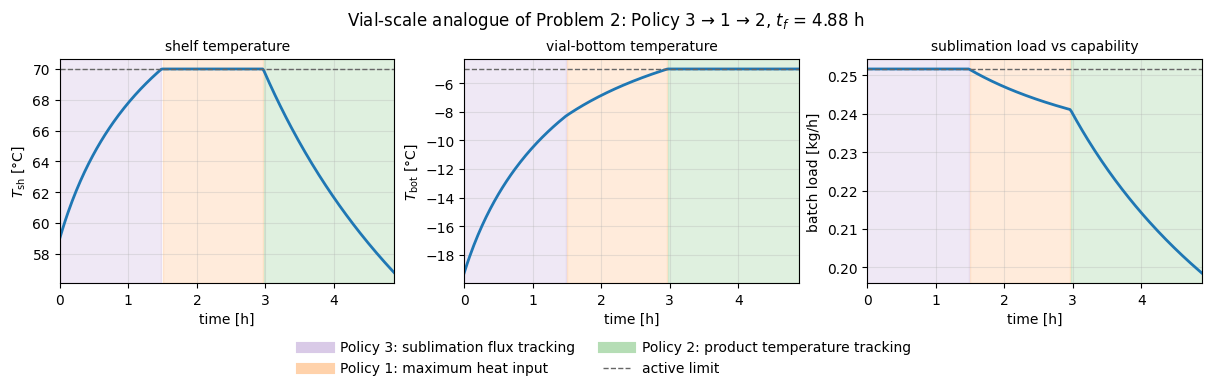

In [13]:
policy_colors = {
    "policy_1_max_heat_input": "tab:orange",
    "policy_2_temperature_tracking": "tab:green",
    "policy_3_interface_velocity_tracking": "tab:purple",
    "unclassified": "0.8",
}

table = vial_run.trajectory
time_hr = table[:, 0]
data = vial_policy_inputs(
    capability_scale=capability_scale,
    shelf_temperature_max_c=shelf_temperature_max_c,
)

figure, axes = plt.subplots(1, 3, figsize=(12.0, 3.8), layout="constrained")

axes[0].plot(time_hr, table[:, 3], color="tab:blue", linewidth=2.0)
axes[0].axhline(data["tshelf"]["max"], color="0.4", linestyle="--", linewidth=1.0)
axes[0].set_title("shelf temperature", fontsize=10)
axes[0].set_ylabel("$T_\\mathrm{sh}$ [°C]")

axes[1].plot(time_hr, table[:, 2], color="tab:blue", linewidth=2.0)
axes[1].axhline(data["product"]["T_pr_crit"], color="0.4", linestyle="--", linewidth=1.0)
axes[1].set_title("vial-bottom temperature", fontsize=10)
axes[1].set_ylabel("$T_\\mathrm{bot}$ [°C]")

axes[2].plot(time_hr, vial_run.policies["load_kg_hr"], color="tab:blue", linewidth=2.0)
axes[2].plot(time_hr, vial_run.policies["capability_kg_hr"], color="0.4",
             linestyle="--", linewidth=1.0)
axes[2].set_title("sublimation load vs capability", fontsize=10)
axes[2].set_ylabel("batch load [kg/h]")

for axis in axes:
    axis.set_xlabel("time [h]")
    axis.set_xlim(0.0, time_hr[-1])
    axis.grid(alpha=0.3)
    for segment in vial_run.policies["segments"]:
        axis.axvspan(segment["start_time_hr"], segment["end_time_hr"],
                     color=policy_colors[segment["label"]], alpha=0.15)

handles = [
    plt.Line2D([], [], color=policy_colors[segment["label"]], linewidth=8, alpha=0.35,
               label=policy_label(segment["label"]))
    for segment in vial_run.policies["segments"]
]
handles.append(plt.Line2D([], [], color="0.4", linestyle="--", linewidth=1.0, label="active limit"))
figure.legend(handles=handles, loc="outside lower center", ncol=2, frameon=False)
figure.suptitle(
    f"Vial-scale analogue of Problem 2: Policy 3 → 1 → 2, "
    f"$t_f$ = {vial_run.drying_time_hr:.2f} h"
)
plt.show()

## Scope and limitations

**What was reproduced.** Both case studies, at the paper's $n_z = 20$ spatial mesh and cold started, recover the published policy sequences exactly and bracket all three published switch times. After extrapolation to the paper's $S = H$ endpoint, Problem 2 agrees with the published 8.9 h to within a few seconds and Problem 1 falls inside the width of the Figure 2 read it is compared against. The interface-velocity limit in Problem 2 is respected to solver tolerance after the initial point.

**How switch times are compared.** Not as instants. A collocation solution resolves a switch only to the interval between adjacent mesh points, so this notebook reports that interval and locates it from the shelf control rather than the product temperature. The distinction is not cosmetic: a tolerance test on the product temperature places the Problem 1 switch near 2.2 h, while the shelf actually leaves its bound near 2.37 h, which is where the upstream MATLAB event detection puts it.

**What was not reproduced.** This notebook does not implement the paper's algorithm. It solves the same optimal control problems by simultaneous collocation, which is the route the paper benchmarks against, so it validates the published *solutions* rather than the published *method*. In particular, the index-2 and index-21 DAE formulations of Policies 2 and 3 never appear here; in the simultaneous formulation the corresponding limits are ordinary inequality path constraints.

**On the terminal endpoint.** The solves stop at $S = 0.995H$ because the transformed equations are singular at $S = H$, and tightening the cutoff to 0.999 costs convergence rather than buying accuracy. The comparison with the paper is therefore made on an extrapolated quantity, justified by its independence of the cutoff rather than by its closeness to the published number. A reader who wants the raw solver output rather than the extrapolation will find both reported side by side.

**On initialization.** Every headline solve is cold started, so the recovered policy sequences are not seeded by the published ones. The policy warm start remains available and reaches the same optimum; the two differ only in the degenerate shelf temperature at $t = 0$.

**On the initial velocity excursion.** Problem 2's velocity constraint is enforced everywhere except the initial collocation point, because the initial state itself violates the limit — $\mathrm{d}S/\mathrm{d}t = 3.8 \times 10^{-7}$ m/s at $t = 0$ against a $2.8 \times 10^{-7}$ m/s cap — and the paper reports the same excursion before Policy 3 pulls the velocity down.

**On the runtime comparison.** Different hardware, and an independent transcription rather than the authors' unreleased optimization scripts. The claim supported here is narrow: a simultaneous collocation transcription of these two problems solves in a small multiple of the simulation-based method's runtime, not three orders of magnitude above it. It is not a claim about optimization-based control in general, and it does not contradict the paper's argument that a method needing no initial guess, no scaling, and no NLP solver is better suited to online use.

**On the vial-scale section.** The equipment-capability line there is deliberately scaled down so that Policy 3 becomes reachable; the measured line never binds for that vial load. The drying times in that section are therefore illustrative of the policy structure, not a validated process recommendation.